<table style="background-color:#F5F5F5;" width="100%">
<tr><td style="background-color:#F5F5F5;"><img src="../images/logo.png" width="150" align='right'/></td></tr>     <tr><td>
            <h2><center>Aprendizagem Automática em Engenharia Física</center></h2>
            <h3><center>1st Semester - 2025/2026</center></h3>
            <h4><center>Universidade Nova de Lisboa - Faculdade de Ciências e Tecnologia</center></h4>
</td></tr>
    <tr><td><h2><b><center>Lab 3 - Genetic Algorithms</center></b></h2>
    <h4><i><b><center>Optimizing Parameters through System Evolution</center></b></i></h4>
    <h5><b>Version Control:</b></h5>
    <h5>Created by: Hugo Gamboa to AAEB</h5>
    <h5>Modified by: Pedro Vieira to AAEF (25/26)</h5>
    </td></tr>
</table>

## 1. Introduction to Genetic Algorithms

### 1.1 What Are Genetic Algorithms?
Genetic Algorithms (GAs) are a type of optimization algorithm inspired by the process of natural selection in biology. They are useful for solving complex problems by mimicking the principles of evolution, such as __selection__, __mutation__, and __crossover__ (exchange of DNA between a pair of homologous chromosomes). Just like in nature, where species evolve to become better suited to their environments, GAs help us find the best solution to a problem by iteratively improving candidate solutions.

### 1.2 Why Use Genetic Algorithms?
Genetic algorithms are particularly useful for problems that:

* Have a large search space (many possible solutions).
* Don’t have a clear mathematical formula for finding the optimal solution.
* Involve multiple competing factors (like cost vs. effectiveness).

In Physics Engineering, GAs can help optimize problems where traditional methods struggle. You can find some example in:
*  https://trace.tennessee.edu/cgi/viewcontent.cgi?article=3824&context=utk_gradthes
*  https://journals.aps.org/prab/abstract/10.1103/PhysRevSTAB.16.010101
*  https://ieeexplore.ieee.org/document/10254090
*  https://iopscience.iop.org/article/10.1088/1475-7516/2012/11/033/meta

### 1.3 How Do Genetic Algorithms Work?
The process of a GA can be broken down into several key steps:

* __Initialization__: Start with a random set of possible solutions, known as the population.
* __Fitness Function__: Each solution is evaluated based on how well it solves the problem (using a fitness function).
* __Selection__: The best solutions are chosen based on their fitness to move on to the next generation.
* __Crossover (Recombination)__: New solutions are created by combining parts of two or more parent solutions.
* __Mutation__: Random changes are made to some solutions to introduce variability.
* __Termination__: The process is repeated until the algorithm finds a solution that meets the desired criteria or after a set number of iterations.

### 1.4 Goals of Today's Class
In today’s practical session, you will learn to apply genetic algorithms to two problems. A more generic one that will be used to give you an understanding on how to implement GAs and one related to Physics Engineering:
* __The Knapsack Problem:__ You will use a GA to optimize the amount of equipment you can fit into your backpack for a camping trip.
* __Optimizing Parameters for Physics Signal Processing:__ You will use a GA to improve how well a filter cleans up a noisy gravitical wave signal.
  
We will guide you through the steps of setting up the genetic algorithm, coding it in Python, and evaluating the results. By the end of the class, you will have a better understanding of GAs and how they can be used in Physics Engineering.

## 2. A Simple Example Of Genetic Algorithms in Use: The Knapsack Problem

Before we start with the exerercises we are going to look at a simple toy example where GAs can be utilized. This example will help you to get familiarized with how GAs can be implemented in Python. For this toy example we will take a look at the __"Knapsack Problem"__. 

The [__Computerphile__](https://www.youtube.com/@Computerphile/videos) channel on YouTube made a great [<u>video</u>](https://www.youtube.com/watch?v=MacVqujSXWE) about it and we will essentially implement what is being discussed in the video. The channel is a great resource if you want to explore computer science topics. (The youtuber behind that channel has also other channels covering topics such as [Maths](https://www.youtube.com/@numberphile), [Physics](https://www.youtube.com/@sixtysymbols), [Chemistry](https://www.youtube.com/@periodicvideos), and [Astronomy](https://www.youtube.com/@DeepSkyVideos), just in case you want to check them out after the class)

### 2.1 Problem Definition

Imagine you have a backpack (knapsack) with a limited capacity, and you are given a set of items, each with a certain weight and value (utility points). The goal is to maximize the total value of the items you can fit in the knapsack without exceeding its weight capacity. The challenge is to find the best combination of items to maximize the value, while respecting the knapsack's weigt capacity.

With regards to the GA steps defined above, we can formulate the Knapsack Problem as a GA, the following way:

* __Initialization__: Start with a population of possible solutions each representing a different combination of items in the knapsack.
* __Fitness Function__: Evaluate each solution based on the total value of the items in the knapsack, but penalize solutions that exceed the weight limit.
* __Selection__: Select the best solutions (those with higher values and within the weight limit) to move to the next generation.
* __Crossover__: Combine solutions to create new ones (for example, taking some items from one solution and others from another).
* __Mutation__: Randomly add or remove items to introduce variability.
* __Termination__: Repeat until the algorithm finds a good solution (e.g., after a set number of generations or when the solution stops improving).


In our toy example we will go an a camping trip. We have __8 items that we can choose to take with us__, however our backpack only has a __maximum weight capacity of 10&nbsp;Kg__. The items with their repsective weights and values (utility points) are shown in the table below

| Item              | Weight (kg) | Value (utility points) |
|-------------------|-------------|------------------------|
| Tent              | 5.0         | 60                     |
| Sleeping Bag      | 2.5         | 40                     |
| Camping Stove     | 3.0         | 30                     |
| Water Bottle      | 1.0         | 10                     |
| First Aid Kit     | 1.5         | 20                     |
| Flashlight        | 0.5         | 15                     |
| Food Supplies     | 4.0         | 50                     |
| Jacket            | 1.5         | 25                     |

|Maximum Backpack Weight Capacity: | 10 Kg|
|----------------------------------|------|

### 2.2 Representing the Data as "Gene Vectors"
In order to solve the Knapsack Problem using a genetic algorithm, we need a way to represent potential solutions (or individuals) as a chromosome with  set of "genes" that can be evolved over time. In the case of the Knapsack Problem we can choose to represent (or encode) the potential solution as a binary vector, where each position in the vector represents whether or not a particular item is included in the knapsack.

Since we have 8 items for our camping trip, the gene vector will have a length of 8. Each element in the vector will be either:

* __1__: The item is included in the knapsack.
* __0__: The item is not included in the knapsack.

For example, let's consider the following binary vector: [1, 0, 1, 0, 0, 1, 0, 1]

This vector represents a possible solution to the problem. In this case:

| Item              | Item Number | Vector Position | Item State   | Binary Vector |
|-------------------|:-----------:|:---------------:|--------------|:-------------:|
| Tent              | 1           | 0               | included     |1              |
| Sleeping Bag      | 2           | 1               | not included |0              |
| Camping Stove     | 3           | 2               | included     |1              |
| Water Bottle      | 4           | 3               | not included |0              |
| First Aid Kit     | 5           | 4               | included     |0              |
| Flashlight        | 6           | 5               | not included |1              |
| Food Supplies     | 7           | 6               | not included |0              |
| Jacket            | 8           | 7               | included     |1              |


As stated above, the binary vector describing the individual represents __one possible solution__. With the genetic algorithm, we will created multiple individuals and then let these evolve over several generations to find the optimal solution.

The usage of binary encoding is a good choice for the Knapsack Problem as in this case an item can only take a binary state. Either the item is included in the backpack or not. Furthermore the chosen encoding has has the following properties:

* __Simplicity__: A binary vector is simple to manipulate and clearly shows which items are selected.
* __Evolution__: We can easily apply genetic operators like mutation (flipping 0 to 1 or 1 to 0) and crossover (combining parts of two parent solutions) to these binary vectors.
* __Evaluation__: Calculating the total weight and value of selected items is straightforward — we simply sum the weights and values of the items corresponding to 1s in the vector.

Depending on the problem that you try to solve, other encodings might be more benefical. If you want to find out about other encodings for genetic algorithms you can ask [ChatGPT](https://chatgpt.com/), [Claude](https://claude.ai/login), [Perplexity](https://www.perplexity.ai/), [Elicit](https://elicit.com/welcome), or any other LLM of your choice, or just do a simple Google search. Here is an exemplarly prompt that you could use. You can adapt it to better suit your needs.

__Prompt__: _"What types of encoding are used for genetic algorithms? Please give me for each encoding a general overview, then the corresponding mathematical description, and finally some use cases in which each encoding is used. If suitable, include examples from the field of Physics Engineering._"

### 2.3 Implementing the Knapsack Problem in Python: Step-By-Step

Now that we have discussed the core concepts, we can start implementing the genetic algorithm using Python. We will do this step-by-step, according to the steps defined in Section 2.1. For each step we will implement a function and then we will finally combine them to a full code example.

#### 2.3.1 Import of Necessary Modules, Set Random Seed, and Definition of Knapsack and Item Properties

As with any Python code, first we need to import the modules we need. The main module we are going to use today is __numpy__. In accordance with Good Programming Practices we will use typing hints, docstrings (in reStructuredText format - you can of course use another format), and will comment our code. 

Since we are going to generate some random numbers later in the code, we will set a random seed. This is needed to make this __code reproducible__. If the seed is set, you will always obtain the same result. In the case of our code we will set the seed through numpy as we will use numpy's random module in the code. Whenever you want to have reproducible results in Machine Learning it is beneficial to report the seed that you used to obtain the results (depending on the modules you use, you'll have to use the seed setting function of that specific module). Often times seed = 42, as a reference to the book "The Hitchhiker's Guide to the Galaxy", but you can set it to any number you like.

Additionally, we will define the knapsack and item properties according to the table above, so that we can use them later in the code:

In [1]:
# import needed modules for the code
import numpy as np
from typing import Optional, Tuple, Dict, Union, List
import matplotlib.pyplot as plt
from tqdm import tqdm  # module for showing neat progress bar when for loops are running

# Set the seed for reproducibility
random_seed = 42

# define knapsack and item properties
item_weights = np.array([5.0, 2.5, 3.5, 1.0, 1.5, 0.5, 4.0, 1.5])
item_values = np.array([60, 40, 30, 10, 20, 15, 50, 25])
max_capacity = 10
item_names = ["tent", "sleeping bag", "camping stove", "water bottle", "first aid kit", "flashlight", "food supplies", "jacket"]

#### 2.3.2 Initilalization

Now we will initialize our population of possible solutions/individuals. There are two main parameters that we need to set for initialization. These are:

* __population size__: the number of individuals (possible solutions) in the population
* __num_items__: the number of items that we want to consider in the Knapsack Problem
* __seed__: (Optional) seed for the random number generator to ensure reproducibility.

For the initialization step, we will simply generate __population_size-many__ random solutions and store them in an array. Remember that each solutions is a binary vector. For that purpose we will use numpy's [__random.randint()__](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html) function that allows us to generate vectors/arrays that contain integers in a certain range.

In [2]:
def initialize_population(population_size: int, num_items: int, seed: Optional[int] = None) -> np.ndarray:
    """
    Initialize a population of binary vectors for the Knapsack Problem.

    :param population_size: The number of individuals in the population.
    :param num_items: The number of items in the Knapsack Problem.
    :param seed: Optional seed for the random number generator to ensure reproducibility.
    :return: A 2D NumPy array where each row is a binary vector representing an individual.
    """
    
    # Set the seed for reproducibility
    if seed is not None:
        np.random.seed(seed)
    
    # Initialize a population with random binary vectors
    # passing low=2 will draw numbers out of a uniform distribution using the half open interval [0, 2), meaning it can only draw 0 or 1
    population = np.random.randint(low=2, size=(population_size, num_items))
    
    return population

Just to get an understanding of the function defined above, let's use it with the following parameters. (You can try running the function multiple times with and without the seed to see the difference in output):

* __population_size__: 10
* __num_items__: len(item_names)

In [3]:
# get the number of items (in our example this is 8)
num_items = len(item_names)

# create an initial population
# to run the function without seed, either remove the seed parameter from the line of code or set seed=None
initial_population = initialize_population(population_size=10, num_items=num_items, seed=42)

# print the result
print("The initial population is: \n{}".format(initial_population))

The initial population is: 
[[0 1 0 0 0 1 0 0]
 [0 1 0 0 0 0 1 0]
 [1 1 1 0 1 0 1 1]
 [1 1 1 1 1 1 0 0]
 [1 1 1 0 1 0 0 0]
 [0 0 1 1 1 1 1 0]
 [1 1 0 1 0 1 0 1]
 [1 0 0 0 0 0 0 0]
 [0 1 1 0 1 1 1 1]
 [0 1 0 1 1 1 0 1]]


#### 2.3.2 Fitness Function

Next we will implement the fitness function. Remember that our Knapsack can only carry items up to a specific weight. Thus the fitness function has to fulfill the following steps:

For each individual (potential solution) in the __population__:

1. calculate the sum of the __weights__ for the chosen items.
2. check if the weight is below the weight __capacity__.
3. if the weight exceededs the capacity, __return a fitness score of 0__.
4. if the weight is below or equal to the weight capacity, __calculate the sum of the values__ (utility points) and return this sum as the fitness score.

Therefore, the function needs the following parameters:

* __weights__: A 1D array of item weights.
* __values__: A 1D array of item values (utility points).
* __population__: A 2D array representing the population.
* __max_capacity___: The maximum allowable weight the knapsack can carry.

In [4]:
def calculate_fitness_scores(weights: np.ndarray, values: np.ndarray, population: np.ndarray, max_capacity: int) -> np.ndarray:
    """
    Calculate the fitness score of each individual in the population for the Knapsack Problem.

    The fitness is the total value of selected items, but if the total weight exceeds the knapsack capacity, 
    the fitness is penalized (set to 0).

    :param weights: A 1D array of item weights.
    :param values: A 1D array of item values.
    :param population: A 2D array representing the population (each row is a binary vector of item selections).
    :param max_capacity: The maximum allowable weight the knapsack can carry.
    :return: A 1D array where each entry is the fitness value of the corresponding individual in the population.
    """

    # get the population size
    population_size = population.shape[0]
    
    # initialize an array to store the fitness score of each individual
    # for simplicity we create an array of zeros corresponding to the population size
    fitness_scores = np.zeros(population_size)

    # loop over each individual (potential solution) in the population
    for individual_num, individual in enumerate(population):
        
        # calculate the total weight of the selected items contained in the individual
        total_weight = np.sum(individual * weights)

        # check if the total_weight is below or equal to the capacity
        if total_weight <= max_capacity:

            # calculat the total value of the selected items
            total_value = np.sum(individual * values)

            # assign the total_value as the fitness score
            fitness_scores[individual_num] = total_value
        
        # capacity was exceeded
        else:
            # penalize by setting fitness to 0
            fitness_scores[individual_num] = 0

    return fitness_scores

Let's test the function using the small population we generated and the knapsack and item porperties defined above.

In [5]:
# calculate the fitness scores for the generated population
fitness_scores = calculate_fitness_scores(item_weights, item_values, initial_population, max_capacity)

# get the solution that that has the highest score
idx_best = np.argmax(fitness_scores)

# get the best score
best_score = np.max(fitness_scores)

# get the best solution in the population
best_solution = initial_population[idx_best, :]

# get the items that correspond to that solution
best_solution_items = [item_names[item_num] for item_num in range(len(item_names)) if best_solution[item_num] == 1]

# print the results
print("The calculated fitness scores for all individuals in the population are: {}".format(fitness_scores))
print("The highest value score ({}) was achieved using the following combination: {}".format(best_score, best_solution))
print("This corresponds to the following items: {}".format(best_solution_items))

The calculated fitness scores for all individuals in the population are: [ 55.  90.   0.   0.   0.   0.   0.  60.   0. 110.]
The highest value score (110.0) was achieved using the following combination: [0 1 0 1 1 1 0 1]
This corresponds to the following items: ['sleeping bag', 'water bottle', 'first aid kit', 'flashlight', 'jacket']


#### 2.3.3 Selection

After calculating the fitness of the population, we need to select individuals for reproduction in the next generation. One popular method for doing this is __Tournament Selection__. This method allows us to select individuals with a bias toward stronger solutions while maintaining diversity by occasionally selecting weaker ones. Tournament Selection includes the following steps:

1. __Choose a Random Subset__: First, we randomly choose a small subset of individuals from the population. This subset is called the "tournament."
2. __Comparison__: Within this subset, we compare the fitness of the individuals. The individual with the highest fitness is the "winner" of the tournament.
3. __Winner Selection__: The winner is then selected to move on to the next generation, or to participate in reproduction (such as crossover and mutation) to create new solutions.
4. __Repeat__: This process is repeated until we have selected enough individuals for the next generation.

Here are a couple of reason why tournament selection is a good choice:

* __Favors Strong Solutions__: Since the winner is the individual with the highest fitness within the tournament, stronger solutions are more likely to be selected.
* __Maintains Diversity__: By randomly selecting the tournament participants, weaker solutions still have a chance to be selected, which helps maintain diversity in the population.
* __Adjustable Selection Pressure__: The size of the tournament affects how much we favor stronger solutions:

    __(1) Larger tournaments__: (e.g., 5 individuals) make it more likely that a stronger individual will win.
  
    __(2) Smaller tournaments__: (e.g., 2 individuals) increase the chances of weaker individuals winning, helping to maintain diversity.

There are plenty of other selection algorithms of which each has its pros and cons. A quick prompt to the LLM of your choice will help you find out about that. (This time you can write the prompt yourself)

Considerig the description of the tournament selection above, we need a function with the following parameters:

 * __population__: A 2D array representing the population (each row is an individual solution)
 * __fitness_scores__: A 1D array representing the fitness values of the individuals in the population.
 * __tournament_size__: The number of individuals to randomly select for each tournament.

For simplicty we will select a population that has the same size as the initial population. Additionally, for this function we will not influence the random generators seeds as if we were to do it, the function would always pick the same subset of individuals.

In [6]:
def tournament_selection(population: np.ndarray, fitness_scores: np.ndarray, tournament_size: int) -> np.ndarray:
    """
    Perform tournament selection to choose individuals for the next generation.

    :param population: A 2D array representing the population.
    :param fitness_scores: A 1D array representing the fitness values of the individuals in the population.
    :param tournament_size: The number of individuals to randomly select for each tournament.
    :return: A 2D array of selected individuals (same shape as the input population).
    """
    
    # Number of individuals in the population
    population_size = population.shape[0]

    # Check if tournament size is valid
    if tournament_size > population_size:
        raise IOError("Tournament size must be smaller than the population size.")
    
    # Initialize an array to store selected individuals
    selected_population = np.zeros_like(population)
    
    # Loop to select individuals for the next generation
    for pos in range(population_size):
        
        # Randomly select 'tournament_size' individuals from the population
        tournament_indices = np.random.choice(population_size, size=tournament_size, replace=False)
        
        # Get the fitness values for the individuals in the tournament
        tournament_fitness = fitness_scores[tournament_indices]
        
        # Find the index of the individual with the highest fitness in the tournament
        winner_index = tournament_indices[np.argmax(tournament_fitness)]
        
        # Select the winner and add to the new population
        selected_population[pos] = population[winner_index, :]
    
    return selected_population

With regards to this implementation there are some things that need to be pointed out. Depending on the population size and the selected tournament size:

1. The same individual can be picked several times.
2. When there are multiple individuals in a tournament that have the same score, the first (with regards to their position in the tournament_fitness array) is always chosen.
3. When the tournament size tends to be close to the population size, the propability of picking the same individual in all tournament rounds is high.

These effects can mitigated by picking a larger population size and adeqaute tournament sizes. Nevertheless, let's use the function on the  __init_population__ and the corresponding __fitness_scores__. We will use a __tournament_size=2__.

In [7]:
# get a new population through tournament selection
selected_population = tournament_selection(population=initial_population, fitness_scores=fitness_scores, tournament_size=2)

# print the result
print("The selected population is: \n{}".format(selected_population))

# comparison to the init population (for visual comparison)
print("\nThe initial population was: \n{}".format(initial_population))

# check programmatically if the two populations are the same
populations_are_equal = np.array_equal(initial_population, selected_population)
print("\nThe previous and new populations are equal: {}".format(populations_are_equal))

The selected population is: 
[[1 1 1 0 1 0 0 0]
 [0 1 0 0 0 1 0 0]
 [1 1 1 0 1 0 0 0]
 [0 0 1 1 1 1 1 0]
 [0 1 0 0 0 0 1 0]
 [0 1 0 0 0 0 1 0]
 [1 1 1 0 1 0 1 1]
 [1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0]]

The initial population was: 
[[0 1 0 0 0 1 0 0]
 [0 1 0 0 0 0 1 0]
 [1 1 1 0 1 0 1 1]
 [1 1 1 1 1 1 0 0]
 [1 1 1 0 1 0 0 0]
 [0 0 1 1 1 1 1 0]
 [1 1 0 1 0 1 0 1]
 [1 0 0 0 0 0 0 0]
 [0 1 1 0 1 1 1 1]
 [0 1 0 1 1 1 0 1]]

The previous and new populations are equal: False


#### 2.3.4 Crossover (Recombination)

Now that we have selected individuals it is time to perform the Crossover (Recombination) step. Crossover is the process where two parent solutions combine to create one or more offspring solutions. The idea behind crossover is to mix the "genes" (bits of information) from the parents, potentially leading to better solutions. 

Crossover allows the genetic algorithm to explore new regions of the solution space by combining the traits of different individuals. It mimics biological reproduction, where offspring inherit traits from both parents. By mixing the genes from two good solutions, crossover helps to find even better solutions, while also ensuring genetic diversity in the population. This increases the likelihood of evolving solutions that are closer to the optimal. Crossover is constituted of the following steps:

1. __Pair Selection__: First, we select two parents from the population.
2. __Crossover Point__: A random point, or multiple points, along the binary vector (gene sequence) of each parent is chosen as the crossover point. This point divides the parents into two parts (or more parts).
3. __Swapping Genes__: The genes of the two parents are swapped at the crossover point(s). The genes before the crossover point come from the first parent, and the genes after the crossover point come from the second parent

In our example we will implement __Single-Point Crossover__. For this, one crossover point is randomly selected along the gene sequence. The part of the genes before this point is copied from one parent, and the part after the point is copied from the other parent. Additionally, we will implement the cross over in such a way, that a pair of parents, always creates a pair of offsprings. Here is a simple example of how this crossover would be performed:

    Parent 1: [1, 0, 1, 0, | 1, 1]
    Parent 2: [0, 1, 0, 1, | 0, 0]
    -------------------------------
    Offspring 1: [1, 0, 1, 0, 0, 0] (genes from Parent 1 before the point, Parent 2 after)
    Offspring 2: [0, 1, 0, 1, 1, 1] (genes from Parent 2 before the point, Parent 1 after)

When performing the crossover step not all pairs of individuals in the selected population are chosen to reproduce. Instead a __crossover probability__ (e.g., 80 %) is chosen to control the crossover rate. This allowsfor some individuals to move on to the next generation without changing their genes, which is in particular useful when an individual is particularly strong.

Therefore, we need a function that receives the following inputs:

* __population__: A 2D array representing the population.
*  __crossover_prob__: The probability with which crossover is performed.
*  __seed__: (Optional) seed for the random number generator to ensure reproducibility.

Furthermore, for simplicity we will restrict the input of our function to populations that have an even number of individuals.

In [8]:
def population_crossover(population: np.ndarray, crossover_prob: float, seed: Optional[int] = None) -> np.ndarray:
    """
    Perform single-point crossover on a randomly paired population, ensuring each individual reproduces once.

    :param population: A 2D array representing the population.
    :param crossover_prob: The probability with which crossover is performed.
    :param seed: Optional seed for the random number generator to ensure reproducibility.
    :return: A 2D array representing the new population after crossover.
    """
    
    # check if crossover_prob is <= 1 | only numbers between [0, 1] are allowed to express probablity
    if not (0 <= crossover_prob <= 1):
        raise IOError("The provided crossover_prob has to be <=1. Provided crossover_prob: {}".format(crossover_prob))
    
    # get the number of individuals in the population and how many "genes" each member of the population has
    population_size, num_genes = population.shape

    # check if the population size is even
    if population_size % 2 != 0:
        raise IOError("The population size must be even to perform crossover. Size of provided population: {}".format(population_size))

    # Set the seed for reproducibility
    if seed is not None:
        np.random.seed(seed)

    # get indicies for a random pairing of the population
    pair_indices = _get_random_pair_indices(population_size)

    # initialize a new population array to store offspring
    new_population = np.zeros_like(population)

    # Perform crossover on randomly paired individuals
    for pair in pair_indices:

        # get the indices of the pairs 
        idx_parent_1 = pair[0]
        idx_parent_2 = pair[1]
        
        # select individuals (parents) using the shuffled indices
        parent_1 = population[idx_parent_1]
        parent_2 = population[idx_parent_2]
        
        # Determine whether to perform crossover based on crossover probability
        if np.random.rand() > crossover_prob:
            
            # If no crossover, copy parents to the next generation unchanged
            new_population[idx_parent_1] = parent_1
            new_population[idx_parent_2] = parent_2
        
        else:
            # Perform single-point crossover
            crossover_point = np.random.randint(1, num_genes)
            
            # Create offspring by swapping genes at the crossover point
            offspring_1 = np.concatenate((parent_1[:crossover_point], parent_2[crossover_point:]))
            offspring_2 = np.concatenate((parent_2[:crossover_point], parent_1[crossover_point:]))
            
            # Add offspring to the new population
            new_population[idx_parent_1] = offspring_1
            new_population[idx_parent_2] = offspring_2

    return new_population


def _get_random_pair_indices(population_size: int):
    """
    Generate random pair indices from a population of a given size.
    This function shuffles the indices of the population and reshapes them into a 
    2D array of pairs, where each row contains two indices representing a pair.

    :param population_size: The size of the population for which pairs are to be generated.
    :returns: A 2D numpy array where each row contains a pair of indices from the population.
    """

    # shuffle the population indices to create random pairs
    pair_indices = np.arange(population_size)
    np.random.shuffle(pair_indices)

    # reshape the indicices array to a 2D array of shape [n, 2]
    # as n  is unknown, use -1 for the first dimension so that numpy implicitly infers the dimension
    pair_indices = pair_indices.reshape(-1, 2)

    return pair_indices

Let's use the crossover function on the __selected_population__. We will use a __crossover_prob=0.8 (80%)__. (Try running the crossover function using a crossover_prob=0 and see the result. You will see that in this instance the selected_population and the crossover_population are the same.)

In [9]:
# perform crossover on population
crossover_population = population_crossover(population=selected_population, crossover_prob=0.8, seed=random_seed)

# print the result
print("The crossover population is: \n{}".format(crossover_population))

# comparison to the init population (for visual comparison)
print("\nThe selected population was: \n{}".format(selected_population))

# check programmatically if the two populations are the same
populations_are_equal = np.array_equal(crossover_population, selected_population)
print("\nThe previous and new populations are equal: {}".format(populations_are_equal))

The crossover population is: 
[[1 1 1 0 1 0 1 0]
 [0 1 0 0 0 0 1 0]
 [1 1 1 0 0 0 0 0]
 [0 0 1 1 1 1 1 1]
 [0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [1 1 1 0 1 0 1 0]
 [1 0 0 0 1 0 0 0]
 [0 1 0 0 0 1 0 0]
 [1 0 0 0 0 0 1 0]]

The selected population was: 
[[1 1 1 0 1 0 0 0]
 [0 1 0 0 0 1 0 0]
 [1 1 1 0 1 0 0 0]
 [0 0 1 1 1 1 1 0]
 [0 1 0 0 0 0 1 0]
 [0 1 0 0 0 0 1 0]
 [1 1 1 0 1 0 1 1]
 [1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0]]

The previous and new populations are equal: False


#### 2.3.5 Mutation

In the Mutation Step, we introduce small, random changes to the offspring produced during the crossover step. Mutation is a critical part of the genetic algorithm process because it helps maintain genetic diversity in the population and allows the algorithm to explore new areas of the solution space. 

Without mutation, the population may become too homogeneous (i.e., too similar to each other) after several generations. This could lead to the algorithm getting stuck in a local optimum, meaning that it finds a solution that appears to be the best in its immediate vicinity but isn't the best possible solution overall. Mutation helps prevent this by introducing random variations that can lead to better solutions being discovered. For mutation the following steps are performed:

1. __Probability of Mutation__: Each gene (bit) in an individual's chromosome (binary vector) has a small probability of being flipped (0 → 1 or 1 → 0). This probability is called the mutation rate. Typically, the mutation rate is set to a low value, such as 0.01 or 0.05, meaning that only 1% or 5% of the genes will mutate in a given population.

2. __Gene Modification__: For each individual in the population, every bit in the chromosome is tested independently against the mutation rate. If a mutation occurs, that bit is flipped. For example, if a gene that was originally a 0 is mutated, it changes to 1, and vice versa.

Let's assume after crossover we have the following individual, where __the first and the fifth gene are mutated__:

    Gene Position:       0  1  2  3  4  5  6  7 
    ____________________________________________
    Individual:         [1, 0, 1, 1, 0, 1, 0, 0]
    --------------------------------------------
    Mutated Individual: [1, 1, 1, 1, 0, 0, 0, 0]

Thus, the function we need to develop needs to have two parameters:

* __population__: A 2D array representing the population.
* __mutation_rate__: The probability with which mutation is performed on each gene.

In [10]:
def mutate_population(population: np.ndarray, mutation_rate: float) -> np.ndarray:
    """
    Apply mutation to a population by randomly flipping bits in each individual's chromosome
    with a probability equal to the mutation rate.

    :param population: A 2D NumPy array where each row represents an individual in the population (binary vector).
    :param mutation_rate: A float representing the probability of mutation for each gene (bit).
    :return: A mutated 2D NumPy array representing the new population after mutation.
    """

    # check if mutation_rate is <= 1 | only numbers between [0, 1] are allowed to express probablity
    if not (0 <= mutation_rate <= 1):
        raise IOError("The provided mutation_rate must be <=1. Provided mutation_rate: {}".format(mutation_rate))
    
    # get the shape of the population (number of individuals and number of genes)
    population_size, num_genes = population.shape
    
    # create a random matrix for mutation decisions 
    # (this will generate a matrix of the same size as the population containing values between [0,1])
    mutation_matrix = np.random.rand(population_size, num_genes)
    
    # create a mask where mutation decisions are below the mutation rate
    # (the mask is a boolean mask that contains only True and False values. It can be used for indexing)
    mutation_mask = mutation_matrix < mutation_rate
    
    # make a copy of the population
    mutated_population = np.copy(population)
    
    # flip the bits at positions where the mask is True
    mutated_population[mutation_mask] = 1 - mutated_population[mutation_mask]

    #print(mutation_mask)
    #print(mutated_population)
    #print(mutated_population[mutation_mask])
    
    
    return mutated_population

As we have done before, we will test the function. We will pass the __crossover_population__ and use a __mutation_rate=0.05__.

In [11]:
# apply mutation of genes to the population
mutated_population = mutate_population(population=crossover_population, mutation_rate=0.05)

# print the result
print("The mutated population is: \n{}".format(mutated_population))

# comparison to the init population (for visual comparison)
print("\nThe crossover population was: \n{}".format(crossover_population))

# check programmatically if the two populations are the same
populations_are_equal = np.array_equal(crossover_population, mutated_population)
print("\nThe previous and new populations are equal: {}".format(populations_are_equal))

The mutated population is: 
[[1 1 1 0 1 0 1 0]
 [0 1 0 0 0 0 1 0]
 [0 1 1 0 0 0 0 0]
 [0 0 1 1 1 0 1 1]
 [0 1 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0]
 [1 1 1 0 1 0 1 0]
 [1 0 0 1 1 0 0 0]
 [0 1 0 0 0 1 0 0]
 [1 0 0 0 0 0 1 0]]

The crossover population was: 
[[1 1 1 0 1 0 1 0]
 [0 1 0 0 0 0 1 0]
 [1 1 1 0 0 0 0 0]
 [0 0 1 1 1 1 1 1]
 [0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [1 1 1 0 1 0 1 0]
 [1 0 0 0 1 0 0 0]
 [0 1 0 0 0 1 0 0]
 [1 0 0 0 0 0 1 0]]

The previous and new populations are equal: False


#### 2.3.6 Termination

The code that we have written and executed above consitutes one iteration of a genetic algorithm. Each iteration is also called __"generation"__ as what we did was starting with an __initial population__ and obtained a __mutated population__/__new_population__. A genetic algorithm runs for several generations until a stopping criterion is met. Below you can find some suitable stopping criteria:

* __Number of Generations__: The algorithm stops after a fixed number of generations. This is a straightforward approach and ensures that the algorithm does not run indefinitely.
* __Convergence__: The algorithm stops when the population converges, meaning there is little or no improvement in the best fitness score over a specified number of generations. This indicates that the algorithm has potentially found a good solution and further iterations may not yield significant improvements.
* __Target Fitness__: The algorithm stops when an individual with a fitness score that meets or exceeds a predefined target fitness level is found. This criterion ensures that the algorithm stops once an acceptable solution is discovered.
* __Diversity Loss__: The algorithm stops when the diversity of the population falls below a certain threshold, meaning that the population has become too homogeneous and lacks variability.
* __Elapsed Time__: The algorithm stops after a predefined amount of time has passed. This can be useful when computational resources are limited or when a solution needs to be found within a specific time frame.


### 2.3 Exercises

__Exercise 1__:
As you now know how each step is implemented, it is time for you to put everything together into an overall function that incorporates the functions from above. You will implement this function using the __number of generations__ as convergence criterion.

__Tasks__:

* Implement a function that runs the entire GA for the Knapsack Problem
* The function should have the following parameters: 
     >* __knapsack_properties__: Dictionary containing the properties of the knapsack (item weights, item values, item names, max capacity).
     >* __population_size__: The number of individuals in the population.
     >* __tournament_size__: The number of individuals to randomly select for each tournament.
     >* __crossover_prob__: The probability with which crossover is performed.
     >* __mutation_rate__:  A float in the range [0, 1] representing the probability of mutation for each gene (bit).
     >* __num_generations__: The number of generations for which the genetic algorithm should run
     >* __seed__: (Optional) seed for the random number generator to ensure reproducibility.

 
* The function should output the following:
    >* __best_fitness_scores__: A List containing the best fitness score for each generation.
    >* __best_items__: A List containing the items that achieved the highest fitness score over all generations.

* The function should be called __knapsack_genetic_algorithm__.
* Don't forget to add a __docstring__, __typing hints__, and __comments__.

The dictionary containing the knapsack properties is defined below:

__Hints__:

* Hint 1: For storing the best_fitness_scores and best_items you could use lists that you can update in each generation if it is needed. (The best_items only need to be updated if the fitness score of the current generation is better than the previous generation's score)
* Hint 2: Some of the code written above might help you in getting the best_fitness_scores for each generation and finding the best_items
corresponding to that score. We suggest wrapping that code into its own function.
* Hint 3: Whenever you are writing code, try writing it as memomry efficient as possible. Contrary to what we did above, always storing the "evolved population" (initial_population, selected_population, etc.) into a new variable is not recommended. Instead one variabale that holds the population (and is overwritten when needed) should be enough.
* Hint 4: Given that the knapsack properties dictionary contains multiple types, the typing hint for it is not obvious. You might want to consider asking the LLM of your choice for some help.
* Hint 5 (Optional): Use the [__tqdm__](https://www.askpython.com/python-modules/python-progress-bars-with-tqdm) module to display a progress bar when running the for loop that runs over the number of generations.

In [12]:
# defining knapsack dictionary keys as constants 
# (these are defined as constants as they will stay static throughout the entire runtime of the code)
ITEM_WEIGHTS = 'item_weights'
ITEM_VALUES = 'item_values'
ITEM_NAMES = 'item_names'
MAX_CAPACITY = 'max_capacity'

# definition of the knapsack properties as dictionary
knapsack_properties = {ITEM_WEIGHTS: np.array([5.0, 2.5, 3.5, 1.0, 1.5, 0.5, 4.0, 1.5]), 
                       ITEM_VALUES: np.array([60, 40, 30, 10, 20, 15, 50, 25]),
                       ITEM_NAMES: ["tent", "sleeping bag", "camping stove", "water bottle", "first aid kit", "flashlight", "food supplies", "jacket"], 
                       MAX_CAPACITY: 10}

# reminder: to access the needed property from the dictionary you need to use the corresponding key
# e.g., item_weights = knapsack_properties[ITEM_WEIGHTS]

In [13]:
def knapsack_genetic_algorithm(knapsack_dict: Dict[str, Union[np.ndarray, List[str], float]], population_size: int, tournament_size: int, 
                               crossover_prob: float, mutation_rate: float, num_generations: int, seed: Optional[int] = None):
    """
    Solves the knapsack problem using a genetic algorithm approach. It evolves a population of potential 
    solutions over a specified number of generations to maximize the total value of items selected 
    within a weight capacity.
    The function proceeds through the following steps:
    1. Initializes the population randomly based on the number of items available.
    2. Evolves the population over `num_generations` by calculating fitness scores, selecting individuals using 
       tournament selection, applying crossover, and performing mutations.
    3. Tracks and updates the best fitness score and items in each generation.
    4. Returns the best fitness scores and corresponding items at the end of all generations.

    :param knapsack_dict: A dictionary containing the knapsack problem parameters:
        - 'item_weights' (np.ndarray): Array of item weights.
        - 'item_values' (np.ndarray): Array of item values.
        - 'max_capacity' (float): Maximum capacity of the knapsack.
        - 'item_names' (List[str]): List of item names corresponding to the weights and values.
    :param population_size: Size of the population to be generated in each generation.
    :param tournament_size: Number of individuals to compete in tournament selection.
    :param crossover_prob: Probability of crossover between individuals during reproduction.
    :param mutation_rate: Rate at which mutation occurs in individuals during evolution.
    :param num_generations: Number of generations for which the genetic algorithm will evolve the population.
    :param seed: Optional seed for random number generation to ensure reproducibility. Defaults to None.

    :returns: A tuple containing:
        - A list of the best fitness scores (List[int]) from each generation.
        - A list of the best items (List[str]) selected by the algorithm across all generations.
    """
    # Set the seed for reproducibility
    if seed is not None:
        np.random.seed(seed)

    # lists for holding fitness score and the best items
    best_fitness_scores = []
    best_items = []

    # variable for storing current best fitnes score
    curr_best_fitness_score = 0

    # get the needed knapsack properties from the dictionary
    item_weights = knapsack_properties[ITEM_WEIGHTS]
    item_values = knapsack_properties[ITEM_VALUES]
    max_capacity = knapsack_properties[MAX_CAPACITY]
    item_names = knapsack_properties[ITEM_NAMES]

    # get the total number of items of which it can be chosen from
    num_items = len(item_names)

    # initialize the population
    population = initialize_population(population_size=population_size, num_items=num_items, seed=seed)

    # cycle over the number of generations
    # using tqdm to show a neat progess bar while the for loop is running
    for gen in tqdm(range(num_generations)):

        # calculate fitness score
        fitness_scores = calculate_fitness_scores(weights=item_weights, values=item_values, population=population, max_capacity=max_capacity)

        # get the best score and corresponding items of the current generation
        best_score_gen, best_items_gen = get_best_score_and_items_generation(fitness_scores, population, item_names)

        # update best_fintess_scores
        best_fitness_scores.append(best_score_gen)

        # check if the best score of the generation is higher than the current best score (best score achieved so far)
        if best_score_gen > curr_best_fitness_score:

            # update the best items achieved so far
            best_items = best_items_gen

            # update the current best score
            curr_best_fitness_score = best_score_gen
            
        # select indivduals
        population = tournament_selection(population=population, fitness_scores=fitness_scores, tournament_size=tournament_size)
        
        # perform crossover
        population = population_crossover(population=population, crossover_prob=crossover_prob, seed=seed)

        # perform mutation
        population = mutate_population(population=population, mutation_rate=mutation_rate)

    return best_fitness_scores, best_items


def get_best_score_and_items_generation(fitness_scores: np.ndarray, population: np.ndarray, item_names: List[str]) -> Tuple[int, List[str]]:
    """
    Finds the individual (solution) with the best fitness score in the current generation and returns 
    the corresponding score and selected items.

    :param fitness_scores: A numpy array containing the fitness scores of the population.
    :param population: A 2D numpy array representing the population, where each row is an individual (solution) 
                       and each column represents an item (1 if selected, 0 if not).
    :param item_names: A list of item names corresponding to the items in the population.

    :returns: A tuple containing:
        - The best fitness score (int) in the current generation.
        - A list of item names (List[str]) corresponding to the selected items of the best individual (solution).
    """

    # get the index of the best fitness score
    idx_best = np.argmax(fitness_scores)

    # get the best score
    best_score_generation = np.max(fitness_scores)

    # get the best individual (solution) in the population
    best_individual = population[idx_best, :]

    # get the items corresponding to that solution
    best_items_generation = [item_names[item_num] for item_num in range(len(item_names)) if best_individual[item_num] == 1]

    return best_score_generation, best_items_generation

__Exercise 2__:
Now it is time to test your function.

__Tasks__:

* Run the the function with different parameters to investigate how the output changes. Which is the highest score you can achieve?
* Print the highest fitness score (utility points) and the best items.
* Plot the best_fitness_scores to show how the scores evolve over the generations. Add approriate labeling for the x- and y-axis, and add a title.

100%|█████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 597.69it/s]

The best fitness score (utility points) achieved was: 150.0
The best items corresponding to that score are: ['sleeping bag', 'first aid kit', 'flashlight', 'food supplies', 'jacket']

The best items corresponding to that score are: [np.float64(135.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(150.0), np.floa

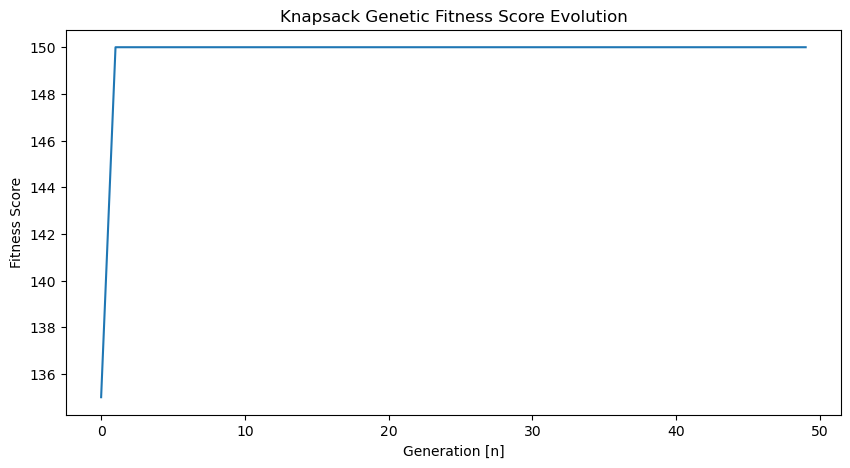

In [14]:
# run the knapsack genetic algorithm
best_fitness_scores, best_items = knapsack_genetic_algorithm(knapsack_dict=knapsack_properties, population_size=30, tournament_size=12, 
                                                             crossover_prob=0.8, mutation_rate=0.05, num_generations=50, seed=42)

# inform user about the achieved results
print("The best fitness score (utility points) achieved was: {}".format(np.max(best_fitness_scores)))
print("The best items corresponding to that score are: {}\n".format(best_items))
print("The best items corresponding to that score are: {}\n".format(best_fitness_scores))

# plot best_fitness_scores
plt.figure(figsize=(10, 5))
plt.plot(best_fitness_scores)
plt.xlabel("Generation [n]")
plt.ylabel("Fitness Score")
plt.title("Knapsack Genetic Fitness Score Evolution")
plt.show()

## 3. Optimizing Filter Parameters for Noise Removal in Pulsar Signals

The pulsar signal can be the recording radio waves that reach earth due to the rotation of a neutron star. Radio waves from pulsars reveal the star’s rotation and slowdown rates, which in turn provide information about the neutron star’s magnetic field and plasma environment. As the waves travel through space, they pick up dispersion and scattering effects that let astronomers measure the density and turbulence of the interstellar medium. These precise pulse timings can also uncover binary companions.

An ideal pulsar signal is clean and exhibits clear peaks. However but in practice, thay can contain significant amount of noise t, __making it difficult to interpret the signal accurately__.

The example we are going to explore today is relatively, simple as we are only going to tackle one particular type of noise source, but it showns how genetic algorithms can be helpfull in the optimisation of those filteres.

### 3.1 Common Noise Sources in pulsar Signals

Noise sources that can be commonly found in pulsar signals are:

* __Interstellar medium (ISM) turbulence__: scattering and dispersion caused by irregularities in ionized gas between stars.
* __Receiver and telescope noise__:thermal noise from electronics, amplifiers, and the antenna system.
* __Sky background noise__: diffuse radio emission from the Milky Way, especially strong at low frequencies.
* __Radio‑frequency interference (RFI)__ human‑made signals such as satellites, communication systems, and electronics.
* __Pulse jitter and intrinsic variability__ natural pulse‑to‑pulse fluctuations produced in the pulsar’s magnetosphere.

For this example we will focus on __Receiver and telescope noise__ and __Radio‑frequency interference (RFI)__ noise, which is a type of __high-frequency noise__ commonly observed in pulsar recordings. typically this noise is removed using __low-pass filter__ but its optimal cutoff frequency and order must be determined.

### 3.2 Low-Pass Fitlers and Their Role in Pulsar Signal Processing

A low-pass filter is a type of filter that allows low-frequency components of a signal to pass through while attenuating (reducing) the amplitude of higher-frequency components. In the context of pulsar signal processing, low-pass filters are used to remove high-frequency noise while retaining the important lower-frequency features of the signal. 

A low-pass filter has two parameters:

* __Cutoff Frequency__: The key parameter of a low-pass filter is the cutoff frequency. Frequencies bellow this threshold are allowed to pass, while frequencies above it are attenuated.

* __Filter Order__: The filter order controls how sharp the cutoff is. A higher filter order results in a steeper transition from the passband (low frequencies) to the stopband (high frequencies). However, higher orders can introduce phase distortion, so a balance must be found between a steep cutoff and minimal signal distortion.

Our goal is to __optimize__ the filter’s parameters, __cutoff frequency__ and __filter order__, using a genetic algorithm.

### 3.3 Signal-to-Noise Ration (SNR)

To evaluate the effectiveness of the filter, we will measure the __Signal-to-Noise Ratio (SNR)__, compares the level of the desired signal to the level of the noise. SNR is a widely used metric in signal processing to quantify the clarity of the signal after filtering. A high SNR indicates, that a signal is of good quality (has low noise).

The SNR, measured in __dB (decibel)__ can be calculated as follows:

$$
\text{SNR} = 10 \cdot \log_{10} \left( \frac{\text{Signal Power}}{\text{Noise Power}} \right)
$$

With:

$$
\text{Signal Power} = \frac{1}{N} \sum_{i=1}^{N} x[i]^2,
$$

$$
\text{Noise Power} = \frac{1}{N} \sum_{i=1}^{N} \left( \hat{x}[i] - x[i] \right)^2
$$

Where: 
- \\( N \\) is the total number of samples in the signal.
- \\( x[i] \\) is the amplitude of the clean signal at the \(i\)-th sample.
- \\( \hat{x}[i] \\) is the filtered (noisy) signal.

In this example, the GA will use __SNR as the fitness function__. The filter parameters will be optimized to maximize the SNR, ensuring that the filtered pulsar signal has minimal noise and retains its important features.

__Note:__ This SNR measurement requires knowing what the signal looks like without noise, which is usually not available. Other SNR definitions can be used that rely only on the noisy measured signal and on assumptions about basic signal characteristics, such as its frequency distribution. 

### 3.4 Exercises

Now it is up to you to write a genetic algorithm from scratch. Just to re-iterate, your goal will be:

* __Parameters to Optimize__: You will be using a GA to optimize the __cutoff frequency__ and __filter order__ to remove baseline wander noise from a pulsar signal.
* __Fitness Function__: As the fitness function you will use the __SNR__. A __high SNR__ indicates that the signal is of __good quality__.

But before we start writing the GA let's get familiarized with the signals and write some functions.

In [15]:
# imports (only importing additional modules that are needed all other modules were imported above)
from scipy import signal # this module will be needed for the low-pass filter
import math

__Exercise 1__:
Get yourself acquainted with the signals that we are working with. In the Data folder you can find two numpy files containing the same signal.

* __Lab3_pulsar_signal.csv__: contains the clean (noise-free) pulsar signal
* __Lab3_pulsar_signal_noisy.csv__: contains the same signal, but corrupted by noise

Both signals were acquired with a sampling frequency of $f_s=1000 Hz$.

__Tasks__:

* Define the sampling frequency as a constant (as it will remain static throughout the entire code runtime).
* Write a function that plots the two signals into the same plot:
    >* Call the function __plot_pulsar_signal_comparison__.
    >* The function should receive as input the clean and noisy signal.
    >* Add approriate labeling for the x- and y-axis, a title, and a legend. The signals should be named accordingly in the legend.
* Load both signals.
* Plot the signals usig your function


__Hints__:
* Hint 1: Use the [numpy.loadtxt()](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html) function to load the data
* Hint 2: Use [matplotlib.pyplot.plot()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) for plotting the data.
* Hint 2: The [matplotlib.pyplot.plot()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) function has a parameter that allows for definiton of a legend label.

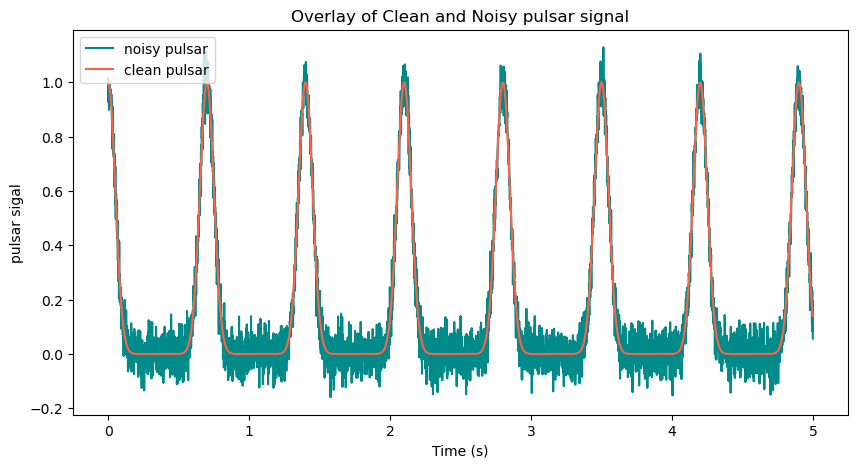

In [16]:
# define constants
FS = 1000

def plot_pulsar_signal_comparison(clean_pulsar: np.array, noisy_pulsar: np.array) -> None:
    """
    Plot and compare clean and noisy pulsar signals. This function creates an 
    overlay plot of a clean pulsar signal and its corresponding noisy version.

    :param clean_pulsar: The clean pulsar signal, represented as a 1D array.
    :param noisy_pulsar: The noisy pulsar signal, represented as a 1D array.
    :return: None
    """
    # create figure
    plt.figure(figsize=(10, 5))

    # plot the clean and noisy pulsar
    plt.plot(clean_pulsar[:,0], clean_pulsar[:,1], label='noisy pulsar', color='darkcyan')
    plt.plot(noisy_pulsar[:,0], noisy_pulsar[:,1], label='clean pulsar', color='tomato')

    # add labels, title, and legend
    plt.xlabel("Time (s)")
    plt.ylabel("pulsar sigal")
    plt.title("Overlay of Clean and Noisy pulsar signal")
    plt.legend(loc='upper left')
    plt.show()


# ---CODE STARTS HERE ---#
# load the two pulsar signals
clean_pulsar = np.loadtxt("../Data/Lab3_pulsar_signal.csv", delimiter=",", dtype=np.float64)
noisy_pulsar = np.loadtxt("../Data/Lab3_pulsar_signal_noisy.csv", delimiter=",", dtype=np.float64)

# plot the signals
plot_pulsar_signal_comparison(noisy_pulsar, clean_pulsar)

__Exercise 2__:
Write a function that calculates the SNR as defined above.

__Tasks__:
* The function should have as input:
    >* __clean_pulsar__: the clean pulsar signal. (Type: np.array)
    >* __filtered_pulsar__: the filtered pulsar signal (Type: np.array)
* The function should output:
    >* __snr__: the SNR rounded to the second digit after the comma.
* Call the function __calc_snr__.
* Calculate the SNR between the original clean and noisy signal. (you can pass the noisy signal as the "filtered_signal".)
* Print the result.

__Hints__:
* Have a good look at the formulas defined above, some terms cancel each other out.
* There is a case for which the calculation of the SNR is not possible. Add a ValueError exception for this case.
* The python __math__ module has a [math.log()](https://docs.python.org/3/library/math.html) function that you can use.
* The numpy module has a [numpy.sum()](https://numpy.org/doc/stable/reference/generated/numpy.sum.html) function.
* The numpy module has a [numpy.round()](https://numpy.org/doc/stable//reference/generated/numpy.round.html) function.
* To square a value in python you simply have to use the ** operator. (e.g.: x_squared = x**2)

In [17]:
def calc_snr(clean_pulsar: np.array, filtered_pulsar: np.array) -> float:
    """
    Calculate the signal-to-noise ratio (SNR) between a clean pulsar signal and a filtered pulsar signal.
    The SNR is computed as the ratio of signal power to noise power, expressed in decibels (dB).

    :param clean_pulsar: The original, clean pulsar signal.
    :param filtered_pulsar: The filtered pulsar signal.
    :return: The SNR value in decibels.
    """

    # calculate the signal and noise power
    signal_power = np.sum(clean_pulsar**2)
    noise_power = np.sum((filtered_pulsar - clean_pulsar)**2)

    # check if the noise power is zero
    if noise_power == 0:
        raise ValueError("The calculated noise power is 0, which does not allow for calculation of the SNR."
                         "\nPlease consider using a different signals as inputs.")

    # calaculat the SNR
    snr = 10*math.log((signal_power/noise_power), 10)

    return np.round(snr, 2)

# calculate the SNR between the cleand and noisy pulsar
snr = calc_snr(clean_pulsar[:,1], noisy_pulsar[:,1])

print("The SNR between the clean and noisy pulsar signal is: {} dB".format(snr, 2))


The SNR between the clean and noisy pulsar signal is: 17.5 dB


__Exercise 3__:
Write a function that performs low-pass filtering on the signal.

__Tasks__:
* Call the function __butter_lowpass_filter__
* The function should receive the following inputs:
    >* __pulsar_signal__: 1D numpy array containing the signal that is supposed to be filtered.
    >* __cutoff_freq__: The cutoff frequency of the high-pass filter. (Type: float)
    >* __fs__: The signals sampling rate. (Type: int)
    >* __order__: The order of the filter. (Type: int)
    
* the function should output
    >* __filtered_pulsar_signal__: The filtered pulsar signal.

__Hints__:
* Check out the documentation for the [scipy.signal.butter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) function.
* As the GA will also explore higher order filters, use the second-order sections (sos) output format (see at the bottom of the documentation page)

In [18]:
def butter_lowpass_filter(pulsar_signal: np.array, cutoff: float, fs: int, order: int) -> np.array:
    """
    Apply a high-pass Butterworth filter using second-order sections (SOS) to a given data signal.

    This function uses a Butterworth filter to remove low-frequency components from the input signal
    and is implemented using the second-order sections (SOS) format for improved numerical stability.

    :param pulsar_signal: The input signal to be filtered.
    :type data: np.array
    :param cutoff: The cutoff frequency of the high-pass filter in Hz.
    :type cutoff: float
    :param fs: The sampling frequency of the input signal in Hz.
    :type fs: float
    :param order: The order of the Butterworth filter (default is 5).
    :return: The filtered signal after applying the high-pass filter.
    """
    # Create the Butterworth high-pass filter coefficients in second-order sections (SOS) format
    sos = signal.butter(order, cutoff, btype='low', analog=False, output='sos', fs=fs)

    # Apply the filter using sosfilt
    filtered_pulsar_signal = signal.sosfiltfilt(sos, pulsar_signal) #changed from sosfilt to sosfiltfilt to avoid signal delay

    return filtered_pulsar_signal

Test the butter_lowpass_filter with the following parameters: fs=1000 Hz; cutoff=50; order=4

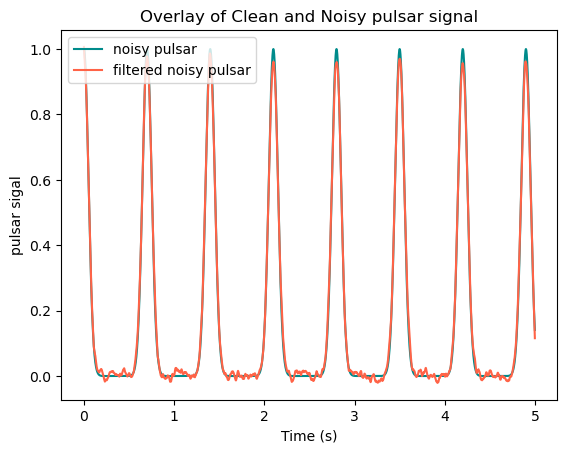

In [19]:
filtered_pulsar_signal = butter_lowpass_filter(noisy_pulsar[:,1], 17, 1000, 1)

plt.plot(clean_pulsar[:,0], clean_pulsar[:,1], label='noisy pulsar', color='darkcyan')
plt.plot(noisy_pulsar[:,0], filtered_pulsar_signal, label='filtered noisy pulsar', color='tomato')

# add labels, title, and legend
plt.xlabel("Time (s)")
plt.ylabel("pulsar sigal")
plt.title("Overlay of Clean and Noisy pulsar signal")
plt.legend(loc='upper left')
plt.show()

__Exercise 4__:
Now you will start implementing the steps of the GA to optimize the filter. First you will start with the population initialization function. Be aware that this time we do not have a binary problem. Instead we have a continuous (for the cutoff frequency) and a discrete (for the filter order) problem as the parameters for the high-pass filter can assume continuous/discrete values. As we already know that we have high frequency noise, the GA does not have to explore the full search space. Thus, we will limit the values we will explore to the following:

* __cutoff frequency (\\(f_c \\))__: \\( f_c \in [1 Hz, 50 Hz)  \\) and \\(f_c \in \mathbb{R} \\) (floating point numbers)
* __order (odr)__: \\( odr\in [1, 5] \\) and \\( odr \in \mathbb{N} \\) (integer numbers)

__Tasks__:
* Define the cutoff frequency and order intervals as constants.
* Write the function for the population initialization.
* call the function __init_population__
* The function should receive the following inputs:
    >* __population_size__: The size of the population. (Type: int)
    >* __fc_range__: The range that should be explored for the cutoff frequencies. (Type: Tuple[float, float])
    >* __order_range__: The range that should be explored for the filter order. (Type: Tuple[int, int])
    >* __seed__: seed for the random number generator to ensure reproducibility.

* The function should output:
    >* __population__: A list of tuples containing the generated population. (Type: List[Tuple[float, int]])

* Test your function by running it with a population_size=10 and print the output

__Hints__:
* Hint 1: You can define the constants for the cutoff frequency and order intervals as tuples. 
* Hint 2: As the parameters you are optimizing have different types (float and int), it is not recommended to store the population into a np.array. We recommend to use a list instead.
* Hint 3: For generating random floats within an interval you should have a look at the [numpy.random.unifrom()](https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html) function. As the function returns numbers with a high precision (several digits after the comma), you should round the output the the second digit after the comma.
* Hint 4: For generating random integers within an interval you should have a look at the [numpy.random.randint()](https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html) function.

In [20]:
# define constants
FC_INTERVAL = (1, 50)
ORDER_INTERVAL = (1, 5)


def init_population(population_size: int, fc_range: Tuple[float, float], order_range: Tuple[int, int], 
                    seed: Optional[int] = None) -> List[Tuple[float, int]]:
    """
    Initializes the population for the genetic algorithm, where each individual
    is represented by a pair of genes: the cutoff frequency and the filter order.

    :param population_size: The size of the population.
    :param fc_range: The range (min, max) of the cutoff frequency (in Hz).
    :param order_range: The range (min, max) of the filter order (integer values).
    :param seed: (Optional) Random seed for reproducibility.
    
    :return: The initialized population, where each individual is represented 
    as a tuple (cutoff frequency, filter order).
    """
    # Set random seed for reproducibility if provided
    if seed is not None:
        np.random.seed(seed)

    # initialize list for holding the population
    population = []
    
    # Generate each individual in the population
    for _ in range(population_size):
        # Randomly choose a cutoff frequency within the specified range
        fc = np.round(np.random.uniform(fc_range[0], fc_range[1]), 2)
        
        # Randomly choose a filter order within the specified range
        order = np.random.randint(order_range[0], order_range[1] + 1)
        
        # Append the individual as a tuple (cutoff frequency, filter order)
        population.append((fc, order))
    
    return population


# Test the function
initial_population = init_population(population_size=10, fc_range=FC_INTERVAL, order_range=ORDER_INTERVAL, seed=42)

print("The initial population is: {}".format(initial_population))

The initial population is: [(np.float64(19.35), 5), (np.float64(9.99), 5), (np.float64(30.25), 2), (np.float64(8.64), 3), (np.float64(23.5), 5), (np.float64(30.45), 3), (np.float64(2.01), 2), (np.float64(36.38), 2), (np.float64(9.91), 5), (np.float64(31.26), 2)]


__Exercise 5__:
Now you will write the function that calculates the fitness scores for each individual within your population. Remeber, the fitness is claculated this time based on the SNR between the clean and the filtered signal. Thus, you will have to use the functions you implemented in __Exercise 2__ and __Exercise 3__.

__Tasks__:
* Call the function __calculate_fitness__.
* The function should receive the following inputs:
    >* __population__: A list of tuples containing the population. (Type: List[Tuple[float, int]])
    >* __clean_pulsar__: The clean pulsar signal. (Type: np.array)
    >* __noisy_pulsar__: The noisy pulsar signal. (Type: np.array)
    >* __fs__: The signals sampling rate. (Type: int)
 
* The function should output:
    >* __fitness_scores__: A list containing the fitness scores for the individuas contained in population. (Type: List[float])
* Test your function by running it with the initial_population you generated in the previous exercise and print out the result

In [21]:
def calculate_fitness(population: List[Tuple[float, int]], clean_pulsar: np.array, noisy_pulsar: np.array, fs: int) -> List[float]:
    """
    Calculate the fitness score (SNR) for each individual in the population.

    :param population: List of tuples, where each tuple contains the cutoff frequency and filter order
                       for an individual in the population.
    :param clean_pulsar: The original, clean pulsar signal.
    :param noisy_pulsar: The noisy pulsar signal that contains baseline wander noise.
    :param fs: The sampling frequency of the pulsar signals.
    :return: A list of fitness scores (SNR values) for each individual in the population.
    """

    # initialize list for holding the fitness scores for the individuals contained in the population
    fitness_scores = []

    # Iterate over each individual in the population
    for individual in population:

        # get the parameters for the high-pass filter
        cutoff_frequency, filter_order = individual

        # Apply the high-pass filter to the noisy pulsar using the individual's genes (cutoff frequency, filter order)
        filtered_pulsar = butter_lowpass_filter(noisy_pulsar, cutoff_frequency, fs, filter_order)

        # Calculate the SNR of the filtered pulsar compared to the clean pulsar
        # as the function throws a ValueError exception we can catch the exception and handle it using a 
        # try-catch block. This way our code will not "break" when the exception occurs. It is very unlikely that this will occur.
        try:
            snr = calc_snr(clean_pulsar, filtered_pulsar)
        except ValueError as e:
            # If noise power is 0 (i.e., filtered signal is identical to the clean signal),
            # assign a very high SNR score as it indicates perfect filtering
            print("Noise power is zero for {}: {}".format(individual, e))
            snr = 100  # Assign a very high fitness score

        # Append the SNR as the fitness score
        fitness_scores.append(snr)

    return fitness_scores


# test code
fitness_scores = calculate_fitness(initial_population, clean_pulsar[:,1], noisy_pulsar[:,1], FS)

print("The fitness scores for the initial population are: {}".format(fitness_scores))

The fitness scores for the initial population are: [np.float64(31.25), np.float64(25.9), np.float64(29.78), np.float64(27.74), np.float64(30.4), np.float64(29.52), np.float64(6.1), np.float64(29.13), np.float64(25.73), np.float64(29.66)]


__Exercise 6__: Now that you have the fitness scores, you can implement the selection step. You will again use __tournament selection__. The tournament selection function we implemented for the knapsack problem can not be used in this case as it uses numpy.arrays for the calculation. This time you have to implement it using the list objects you are using. However, the logic (i.e., pefromed steps) are the same, so you can use the function as a reference.

__Tasks__:
* Implement the tournament selection, adapting it to the new data types you are using.
* Call the function __tournament_selection__.
* The function should receive the following inputs:
    >* __population__: A list of tuples containing the population. (Type: List[Tuple[float, int]])
    >* __fitness_scores__: A list containing the fitness scores for the individuas contained in population. (Type: List[float])
    >* __tournament_size__: The number of individuals to randomly select for each tournament. (Type: int)
* The function should output:
    >* __selected_population__: A list of tuples containing the selected population. (Type: List[Tuple[float, int]])
* Test your function using a __tournament_size=2__ and print the output.

In [22]:
def tournament_selection(population: List[Tuple[float, int]], fitness_scores: List[float], tournament_size: int) -> List[Tuple[float, int]]:
    """
    Perform tournament selection to choose individuals from the population based on fitness scores.

    :param population: List of tuples, where each tuple contains the cutoff frequency and filter order
                       for individuals in the population.
    :param fitness_scores: List of fitness scores corresponding to each individual in the population.
    :param tournament_size: The number of individuals to participate in each tournament.
    
    :return: A list of selected individuals based on the tournament selection process.
    """

    # check if tournament_size is valid
    if tournament_size > len(population):
        raise ValueError("Tournament size must be smaller than the population size.")

    # intialize list for holding selected individuals
    selected_individuals = []

    # Run tournaments until the desired number of selections is achieved
    while len(selected_individuals) < len(population):
        
        # Randomly select individuals for the tournament
        tournament_indices = np.random.choice(len(population), size=tournament_size, replace=False)

        # get fitness scores corresponding the tournament_indices
        tournament_fitness = [fitness_scores[idx] for idx in tournament_indices]
        
        # Determine the best individual in the tournament based on fitness scores
        winner_index = tournament_indices[np.argmax(tournament_fitness)]
        
        # Append the best individual to the selected individuals list
        selected_individuals.append(population[winner_index])
    
    return selected_individuals

# testing function
selected_population = tournament_selection(initial_population, fitness_scores, 2)

print("the selected population is:{}".format(selected_population))

the selected population is:[(np.float64(23.5), 5), (np.float64(9.99), 5), (np.float64(30.25), 2), (np.float64(31.26), 2), (np.float64(31.26), 2), (np.float64(19.35), 5), (np.float64(30.25), 2), (np.float64(30.25), 2), (np.float64(30.45), 3), (np.float64(8.64), 3)]


__Exercise 7__: Next, you need to implement the crossover function. The crossover function in this case will be a bit simpler than in the Knapsack Problem example as each individual just consists of two elements. You basically just have to swap out the second element of the Tuple representing a parent.

__Example__: Let's asume we have the following two parents and their offspring: 

    Parent 1: (0.74, 2)
    Parent 2: (0.20, 3)
    -------------------
    offspring 1: (0.74, 3)
    offspring 2: (0.20, 2)

__Tasks__:
* Implement the crossover function.
* Call the function __crossover__.
* The function should receive the following inputs:
    >* __population__: A list of tuples containing the population. (Type: List[Tuple[float, int]])
    >* __crossover_prob__: The probability with which crossover is performed. (Type: float)
    >* __seed__: seed for the random number generator to ensure reproducibility. (Type: int, Optional)
* The function should return:
    >*  __crossover_population__: A list of tuples containing the crossover population. (Type: List[Tuple[float, int]])
* Test your function using a __crossover_prob=0.8__ and print the output.

__Hints__:
* Hint 1: The function __get_random_pair_indices()__ that we implemented above can be reused in this example.

In [23]:
def crossover(population: List[Tuple[float, int]], crossover_prob: float, seed: Optional[int] = None) -> List[Tuple[float, int]]:
    """
    Perform single-point crossover on a population with a given probability to generate offspring.

    :param population: List of tuples, where each tuple contains the cutoff frequency and filter order
                       for individuals in the population.
    :param crossover_prob: The probability of performing crossover on a pair of parents.
    
    :return: A list of individuals (including offspring and potentially unchanged parents).
    """

    # check if crossover_prob is <= 1 | only numbers between [0, 1] are allowed to express probablity
    if not (0 <= crossover_prob <= 1):
        raise IOError("The provided crossover_prob has to be <=1. Provided crossover_prob: {}".format(crossover_prob))

    # get the population size
    population_size = len(population)

    # check if the population size is even
    if population_size % 2 != 0:
        raise IOError("The population size must be even to perform crossover. Size of provided population: {}".format(population_size))

    # Set the seed for reproducibility
    if seed is not None:
        np.random.seed(seed)

    # initialize list for holding crossover population
    crossover_population = []

    # get indicies for a random pairing of the population
    pair_indices = _get_random_pair_indices(population_size)

    # cycle over the pairs
    for pair in pair_indices:

        # get the indices of the pairs
        idx_parent_1 = pair[0]
        idx_parent_2 = pair[1]

        # select individuals (parents) using the shuffled indices
        parent_1 = population[idx_parent_1]
        parent_2 = population[idx_parent_2]

        # Determine whether to perform crossover based on crossover probability
        if np.random.rand() > crossover_prob:
            
            # If no crossover, copy parents to the next generation unchanged
            crossover_population.append(parent_1)
            crossover_population.append(parent_2)
        
        else:
            
            # Create offspring by swapping the second elements of the parents
            offspring_1 = (parent_1[0], parent_2[1])
            offspring_2 = (parent_2[0], parent_1[1])
            
            # Add offspring to the new population
            crossover_population.append(offspring_1)
            crossover_population.append(offspring_2)

    return crossover_population

# testing the function
crossover_population = crossover(selected_population, 0.8, seed=42)

print("the crossover population is:{}".format(crossover_population))

the crossover population is:[(np.float64(30.45), 5), (np.float64(9.99), 3), (np.float64(19.35), 5), (np.float64(23.5), 5), (np.float64(30.25), 2), (np.float64(30.25), 2), (np.float64(8.64), 2), (np.float64(31.26), 3), (np.float64(31.26), 2), (np.float64(30.25), 2)]


__Exercise 8__: Almost done! Now you have to implement the mutation function. As we are working with continuous and discrete values, the mutation approach we used in the knapsack problem is not adequate. Instead you will implment another approach called __Creep Mutation__. 

__Creep Mutation__: Is a mutation technique where small, incremental changes are applied to a gene's value rather than large, random mutations. It is typically used when the genes represent real numbers or continuous variables, and the mutation is intended to explore nearby regions of the solution space.

In our case we will increse or decrease the variables by adding values from the following ranges
* __cutoff frequency creep (\\( f_{c,cr} \\))__: \\( f_{c,cr} \in [-1 Hz, 1 Hz]  \\) and \\(f_{c,cr} \in \mathbb{R} \\)
* __order creep (\\( odr_{cr} \\))__: \\( odr_{cr}\in [-1, 1] \\) and \\( odr_{cr} \in \mathbb{N} \\)

In the case that the addition of the value taken out of the creep range, results in a value that is outside of the range that we are exploring for the frequency cutoff and the filter order, you will just clip it to the maximum or minimum of the range.

__Example__: Let's have a look at two examples:

    order : 5
    value taken out of the order creep range: 1
    ____________________________________________________
    mutated value: 5 + 1 = 6  --> out of range clip: to 5 (defined range for order: [1, 5])

    frequency cutoff : 0.1 Hz
    value taken out of the frequency creep range: -0.1 Hz
    ____________________________________________________
    mutated value: 0.1 Hz + (-0.1) Hz = 0 Hz  --> out of range clip: to 0.05 Hz (defined range for frequency cutoff: [0.05, 1] Hz)

__Tasks__:
* Define the minimum and maximum of both ranges as constants.
* Write the function for mutating the individuals in the population.
* Call the function __mutate_population__
* The function should have the following parameters:
    >* __population__: A list of tuples containing the population. (Type: List[Tuple[float, int]])
    >* __mutation_rate__: The probability with which mutation is performed on each gene. (Type: float)
    >* __cutoff_range__: The allowed range for the cutoff frequency (min, max). (Type: Tuple[float, float])
    >* __order_range__: The allowed range for the filter order (min, max). (Type: Tuple[float, float])
* The function should return:
    >* __mutated_population__:  A list of tuples containing the population. (Type: List[Tuple[float, int]])
* Test your function using a __mutation_rate=0.1__ and print the result.

__Hints__:
* For selecting creep values for the cutoff frequency, you can use [numpy.random.unifrom()](https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html) with the specified range. Round the creep value for the cutoff frequency to two digits after the comman.
* For selecting creep values for the filter order, you can use [numpy.random.choice()](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) and pass the range as a list. No other parameters are needed.
* For cliping values to a certain range you can use [numpy.clip()](https://numpy.org/doc/stable/reference/generated/numpy.clip.html).

In [24]:
# defining creep ranges minima and maxima
CUTOFF_CR_MIN = -1
CUTOFF_CR_MAX = 1
ORDER_CR_MIN = -1
ORDER_CR_MAX = 1

def mutate_population(population: List[Tuple[float, int]], mutation_rate: float, cutoff_range: Tuple[float, float], order_range: Tuple[int, int]) -> List[Tuple[float, int]]:
    """
    Mutate the population by randomly altering the cutoff frequency or filter order based on a mutation rate.

    :param population: List of tuples, where each tuple contains the cutoff frequency and filter order
                       for individuals in the population.
    :param mutation_rate: The probability of mutating each individual in the population.
    :param cutoff_range: The allowed range for the cutoff frequency (min, max).
    :param order_range: The allowed range for the filter order (min, max).
    
    :return: List[Tuple[float, int]]
        The mutated population.
    """
    mutated_population = []

    for individual in population:

        # get the filter parameters
        cutoff_frequency, filter_order = individual

        # generate a random number between [0, 1] and check if it smaller than the mutation rate
        if np.random.rand() < mutation_rate:
            
            # get creep values for the cutoff and order
            creep_value_cutoff = np.round(np.random.uniform(CUTOFF_CR_MIN, CUTOFF_CR_MAX), 2) 
            creep_value_order = np.random.choice([ORDER_CR_MIN, ORDER_CR_MAX])

            # perform creep mutation 
            new_cutoff = np.round(cutoff_frequency + creep_value_cutoff, 2)
            new_order = filter_order + creep_value_order
            
            # clip the cutoff frequency within the allowed range
            new_cutoff = np.clip(new_cutoff, cutoff_range[0], cutoff_range[1])
            new_order = np.clip(new_order, order_range[0], order_range[1])

            # add the mutated individual to the new population
            mutated_population.append((new_cutoff, new_order))
        
        else:
            # If no mutation, add the individual unchanged
            mutated_population.append(individual)

    return mutated_population


# set mutation rate
mutation_rate = 0.1

# testing the function
mutated_population = mutate_population(population=crossover_population, mutation_rate=mutation_rate, cutoff_range=FC_INTERVAL, order_range=ORDER_INTERVAL)

print("the mutated population is:{}".format(mutated_population))

the mutated population is:[(np.float64(31.39), np.int64(5)), (np.float64(9.99), 3), (np.float64(20.33), np.int64(4)), (np.float64(23.5), 5), (np.float64(30.25), 2), (np.float64(30.25), 2), (np.float64(8.64), 2), (np.float64(31.26), 3), (np.float64(31.26), 2), (np.float64(30.25), 2)]


__Exercise 9__: Final exercise! You made it!! Now it is your task to put everything together. This time you don't need to write a function. Just a code that combines everything you did above.

__Tasks__:
* Combine the code to run the the genetic algorithm.
* Use the __Number of Iterations__ as termination criterion.
* Get the best fitness score of each iteration and save it into a list.
* Get the best filter parameters over all generation.
* Plot the best fitness score over the number of generations.
* Apply the filter with the best parameters to the noisy signal.
* Plot both signals (the clean and the filtered signal) together into one plot.

__Hints__:
* Hint 1: It is beneficial to define all your adjustable parameters at the top of the code, so that you have them all together in one place to change them more effectively.
* Hint 2: Use the [__tqdm__](https://www.askpython.com/python-modules/python-progress-bars-with-tqdm) module to display a progress bar when running the for loop that runs over the number of generations.

In [25]:
# setting seed
random_seed = 42

# setting parameters
population_size = 50
tournament_size = 5
crossover_prob = 0.6
mutation_rate = 0.05
num_generations = 1

# list for holding the best fitness score for each iteration
best_fitness_scores = []

# tuple for holding the best filter parameters
best_filter_param = ()

# variable for holding the current best fitness score
curr_best_fitness_score = 0

# intialize the population 
population = init_population(population_size=population_size, fc_range=FC_INTERVAL, order_range=ORDER_INTERVAL, seed=random_seed)

fitness_scores = calculate_fitness(population, clean_pulsar[:,1], noisy_pulsar[:,1], FS)


Running Genetic Algorithm: 100%|███████████████████████████████████████████████████████| 15/15 [00:01<00:00, 13.22it/s]


(np.float64(13.57), np.int64(2))
The best filter parameters are: cutoff frequency: 13.57 | order: 2


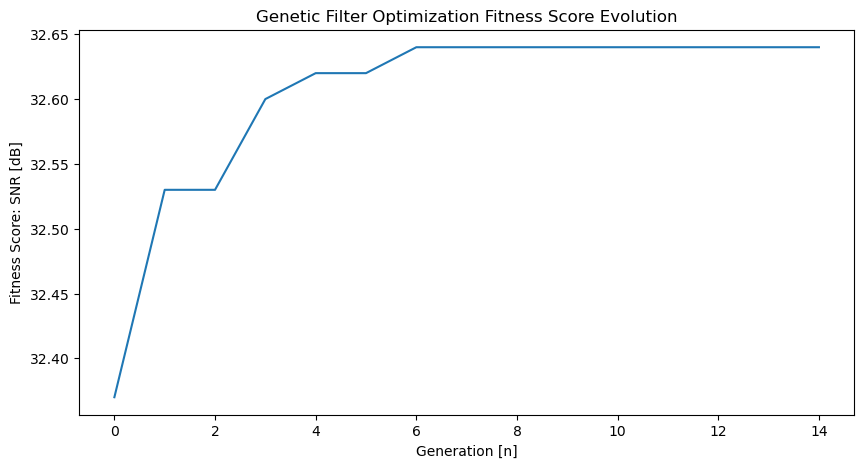

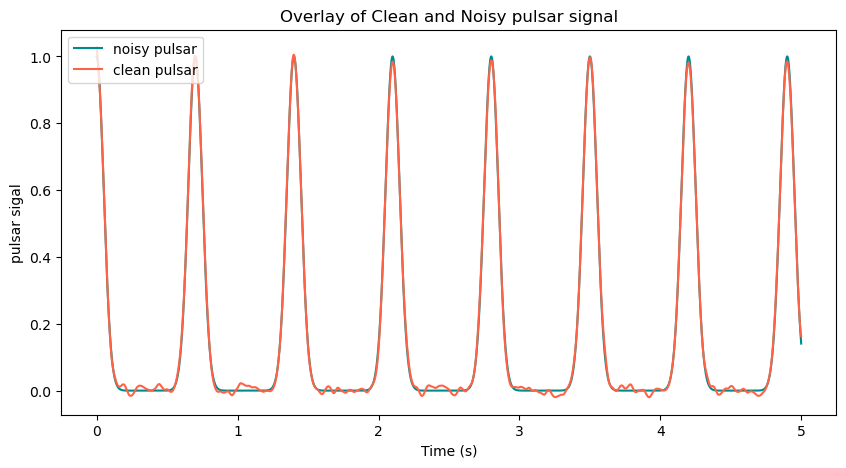

In [26]:
# setting seed
random_seed = 42

# setting parameters
population_size = 50
tournament_size = 5
crossover_prob = 0.6
mutation_rate = 0.05
num_generations = 15

# list for holding the best fitness score for each iteration
best_fitness_scores = []

# tuple for holding the best filter parameters
best_filter_param = ()

# variable for holding the current best fitness score
curr_best_fitness_score = 0

# intialize the population 
population = init_population(population_size=population_size, fc_range=FC_INTERVAL, order_range=ORDER_INTERVAL, seed=random_seed)

# cycle over the number of generations
for gen in tqdm(range(num_generations), desc="Running Genetic Algorithm"):

    # calculate the fitness score 
    fitness_scores = calculate_fitness(population, clean_pulsar[:,1], noisy_pulsar[:,1], FS)

    # get the best fitness score
    best_score_gen = max(fitness_scores)

    # update best_fitness_scores
    best_fitness_scores.append(best_score_gen)

    # check if the best score of the generation is higher than the current best score (best score achieved so far)
    if best_score_gen > curr_best_fitness_score:

        # update the best items achieved so far
        best_filter_param = population[np.argmax(fitness_scores)]

        # update the current best score
        curr_best_fitness_score = best_score_gen

    # select individuals
    population = tournament_selection(population=population, fitness_scores=fitness_scores, tournament_size=tournament_size)

    # perform crossover
    population = crossover(population=population, crossover_prob=crossover_prob, seed=random_seed)

    # perform mutation
    population = mutate_population(population=population, mutation_rate=mutation_rate, cutoff_range=FC_INTERVAL, order_range=ORDER_INTERVAL)


# inform user
print(best_filter_param)
print("The best filter parameters are: cutoff frequency: {} | order: {}".format(best_filter_param[0], best_filter_param[1]))

# plot best_fitness_scores
plt.figure(figsize=(10, 5))
plt.plot(best_fitness_scores)
plt.xlabel("Generation [n]")
plt.ylabel("Fitness Score: SNR [dB]")
plt.title("Genetic Filter Optimization Fitness Score Evolution")
plt.show()

# apply filter to signal
filtered_pulsar = butter_lowpass_filter(noisy_pulsar[:,1], best_filter_param[0], FS, best_filter_param[1])

# plot both signals
filtered_pulsar_2 = np.zeros_like(clean_pulsar)   # create array with same shape
filtered_pulsar_2[:,0] = clean_pulsar[:,0] #get the time column
filtered_pulsar_2[:,1] = filtered_pulsar   #get the data column
plot_pulsar_signal_comparison(clean_pulsar, filtered_pulsar_2)